# Tao dataset_final tu dataset hien tai va BDD100K

Notebook nay loc cac anh/nhan chua class motor, bus, truck, lay mau 30%, va tao thu muc `dataser_final` co cau truc giong dataset goc.

## 1. Thiet lap duong dan va tham so loc lop

Khai bao duong dan dataset hien tai, BDD100K (images/labels), cac lop muc tieu va thu muc dau ra.

In [ ]:
from pathlib import Path
import json
import random
import shutil
from collections import Counter
import cv2
import matplotlib.pyplot as plt

# Dataset hien tai (YOLO)
DATASET_DIR = Path(r"D:\2026\DATN\Data\dataset")
CUR_IMAGES_DIR = DATASET_DIR / "images"
CUR_LABELS_DIR = DATASET_DIR / "labels"

# BDD100K (da map class theo dataset hien tai)
BDD100K_DIR = Path(r"D:\2026\DATN\Data\bdd100k")
BDD_IMAGES_DIRS = [BDD100K_DIR / "images" / "train", BDD100K_DIR / "images" / "val"]
BDD_LABELS_DIRS = [BDD100K_DIR / "labels" / "train", BDD100K_DIR / "labels" / "val"]

# Thu muc dau ra
OUTPUT_DIR = Path(r"D:\2026\DATN\Data\dataser_final")
OUT_IMAGES_DIR = OUTPUT_DIR / "images"
OUT_LABELS_DIR = OUTPUT_DIR / "labels"

# Lop muc tieu (class id theo dataset hien tai)
TARGET_CLASS_IDS = {1, 2, 3}  # truck=1, bus=2, motor=3
SAMPLE_RATIO = 0.30
SEED = 42

IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

BDD100K YOLO images: 79176
BDD100K YOLO labels: 866656
BDD100K YOLO class counts: {0: 815717, 2: 13269, 1: 34216, 3: 3454}


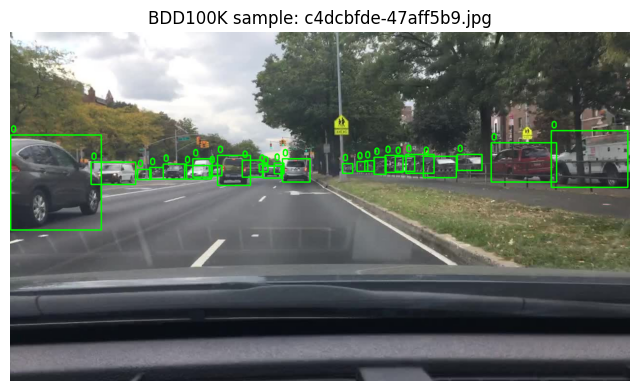

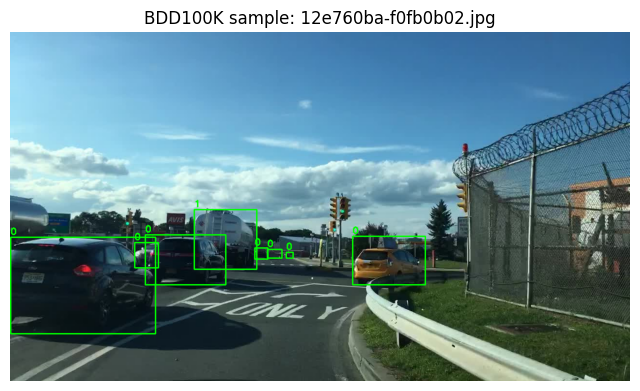

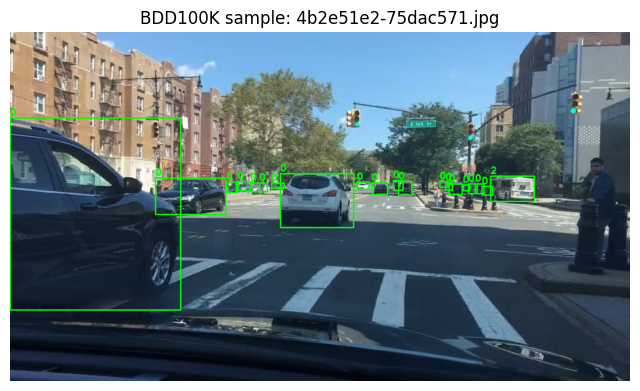

In [2]:
# BDD100K stats and quick visualization (assumes labels already mapped to dataset classes)

def load_yolo_labels_local(label_path: Path):
    labels = []
    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(parts[0])
        x, y, w, h = map(float, parts[1:])
        labels.append((cls_id, x, y, w, h))
    return labels


def bdd_yolo_stats(images_dirs: list[Path], labels_dirs: list[Path]):
    class_counts = Counter()
    total_images = 0
    total_labels = 0
    for images_dir, labels_dir in zip(images_dirs, labels_dirs):
        for label_path in labels_dir.glob("*.txt"):
            labels = load_yolo_labels_local(label_path)
            if not labels:
                continue
            total_images += 1
            total_labels += len(labels)
            for cls_id, *_ in labels:
                class_counts[cls_id] += 1
    return total_images, total_labels, class_counts


def draw_bdd_samples(images_dirs: list[Path], labels_dirs: list[Path], sample_count: int = 3):
    pairs = []
    for images_dir, labels_dir in zip(images_dirs, labels_dirs):
        for label_path in labels_dir.glob("*.txt"):
            img_path = images_dir / f"{label_path.stem}.jpg"
            if img_path.exists():
                pairs.append((img_path, label_path))
                continue
            for ext in IMAGE_EXTS:
                alt_path = images_dir / f"{label_path.stem}{ext}"
                if alt_path.exists():
                    pairs.append((alt_path, label_path))
                    break
    if not pairs:
        print("No BDD100K YOLO pairs found.")
        return

    random.seed(SEED)
    random.shuffle(pairs)
    for img_path, label_path in pairs[:sample_count]:
        img = cv2.imread(str(img_path))
        if img is None:
            print(f"Failed to read image: {img_path}")
            continue
        labels = load_yolo_labels_local(label_path)
        h, w = img.shape[:2]
        for cls_id, x, y, bw, bh in labels:
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, str(cls_id), (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.title(f"BDD100K sample: {img_path.name}")
        plt.axis("off")
        plt.show()


bdd_total_images, bdd_total_labels, bdd_class_counts = bdd_yolo_stats(BDD_IMAGES_DIRS, BDD_LABELS_DIRS)
print(f"BDD100K YOLO images: {bdd_total_images}")
print(f"BDD100K YOLO labels: {bdd_total_labels}")
print("BDD100K YOLO class counts:", dict(bdd_class_counts))

draw_bdd_samples(BDD_IMAGES_DIRS, BDD_LABELS_DIRS, sample_count=3)

## 2. Quet va chuan hoa nhan YOLO tu dataset hien tai

Loc cac anh co it nhat mot bbox thuoc class motor/bus/truck.

In [3]:
def load_yolo_labels(label_path: Path):
    labels = []
    for line in label_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(parts[0])
        x, y, w, h = map(float, parts[1:])
        labels.append((cls_id, x, y, w, h))
    return labels


def filter_yolo_pairs(images_dir: Path, labels_dir: Path, target_class_ids: set[int]):
    pairs = []
    for img_path in sorted(images_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        label_path = labels_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue
        labels = load_yolo_labels(label_path)
        if any(cls_id in target_class_ids for cls_id, *_ in labels):
            pairs.append((img_path, label_path))
    return pairs


cur_pairs = filter_yolo_pairs(CUR_IMAGES_DIR, CUR_LABELS_DIR, TARGET_CLASS_IDS)
print(f"Current dataset pairs (target classes): {len(cur_pairs)}")

Current dataset pairs (target classes): 681


## 3. Doc BDD100K YOLO (da map class)

Chi doc nhan YOLO (.txt) da duoc map san theo class hien tai, khong can map lai.

In [4]:
def read_bdd_yolo_pairs(images_dir: Path, labels_dir: Path):
    pairs = []
    for img_path in sorted(images_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        label_path = labels_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue
        labels = load_yolo_labels(label_path)
        labels = [lb for lb in labels if lb[0] in TARGET_CLASS_IDS]
        if labels:
            pairs.append((img_path, labels))
    return pairs


def collect_bdd_pairs(images_dirs: list[Path], labels_dirs: list[Path]):
    bdd_pairs = []
    for images_dir, labels_dir in zip(images_dirs, labels_dirs):
        bdd_pairs.extend(read_bdd_yolo_pairs(images_dir, labels_dir))
    return bdd_pairs


def count_bdd_yolo_classes(labels_dir: Path):
    counts = Counter()
    for label_path in labels_dir.glob("*.txt"):
        labels = load_yolo_labels(label_path)
        for cls_id, *_ in labels:
            counts[cls_id] += 1
    return counts


def count_bdd_classes(labels_dirs: list[Path]):
    total = Counter()
    for labels_dir in labels_dirs:
        total.update(count_bdd_yolo_classes(labels_dir))
    return total


bdd_pairs = collect_bdd_pairs(BDD_IMAGES_DIRS, BDD_LABELS_DIRS)
print(f"BDD100K pairs (target classes): {len(bdd_pairs)}")

bdd_class_counts = count_bdd_classes(BDD_LABELS_DIRS)
print(f"BDD100K class count (raw): {dict(bdd_class_counts)}")

BDD100K pairs (target classes): 29815
BDD100K class count (raw): {0: 815717, 2: 13269, 1: 34216, 3: 3454}


## 4. Gop nguon du lieu va lay mau 30%

Gop danh sach tu hai nguon, xao tron theo seed co dinh va lay 30%.

In [5]:
all_pairs = []

# Full current dataset (filtered by target classes)
cur_selected = []
for img_path, label_path in cur_pairs:
    labels = load_yolo_labels(label_path)
    labels = [lb for lb in labels if lb[0] in TARGET_CLASS_IDS]
    if labels:
        cur_selected.append((img_path, labels))

# BDD100K: take 30% of filtered pairs
bdd_filtered = []
for img_path, labels in bdd_pairs:
    labels = [lb for lb in labels if lb[0] in TARGET_CLASS_IDS]
    if labels:
        bdd_filtered.append((img_path, labels))

random.seed(SEED)
random.shuffle(bdd_filtered)

bdd_sample_count = int(len(bdd_filtered) * SAMPLE_RATIO)
bdd_selected = bdd_filtered[:bdd_sample_count]

selected_pairs = cur_selected + bdd_selected
print(f"Current selected (100%): {len(cur_selected)}")
print(f"BDD100K eligible: {len(bdd_filtered)}")
print(f"BDD100K selected (30%): {len(bdd_selected)}")
print(f"Total selected pairs: {len(selected_pairs)}")

Current selected (100%): 681
BDD100K eligible: 29815
BDD100K selected (30%): 8944
Total selected pairs: 9625


## 5. Tao thu muc dataser_final va sao chep anh/nhan

Tao cau truc images/labels va ghi nhan YOLO tuong ung.

In [6]:
def save_yolo_labels(label_path: Path, labels):
    lines = [f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for cls_id, x, y, w, h in labels]
    label_path.write_text("\n".join(lines))


def prepare_output_dir(output_dir: Path):
    if output_dir.exists():
        shutil.rmtree(output_dir)
    (output_dir / "images").mkdir(parents=True, exist_ok=True)
    (output_dir / "labels").mkdir(parents=True, exist_ok=True)


def copy_selected_pairs(selected):
    prepare_output_dir(OUTPUT_DIR)
    name_counter = 1
    for img_path, labels in selected:
        # Doi ten de tranh trung neu trung ten giua cac nguon
        new_stem = f"img_{name_counter:06d}"
        name_counter += 1
        out_img = OUT_IMAGES_DIR / f"{new_stem}{img_path.suffix.lower()}"
        out_lbl = OUT_LABELS_DIR / f"{new_stem}.txt"
        shutil.copy2(img_path, out_img)
        save_yolo_labels(out_lbl, labels)


copy_selected_pairs(selected_pairs)
print(f"Saved dataset_final: {len(selected_pairs)} images")

Saved dataset_final: 9625 images


## 6. Kiem tra nhanh so luong va vi du hien thi

Dem so anh/nhan va ve mot vai anh kem bbox de xac thuc.

Final images: 9625
Final labels: 16933
Class counts: {3: 2629, 2: 3931, 1: 10373}


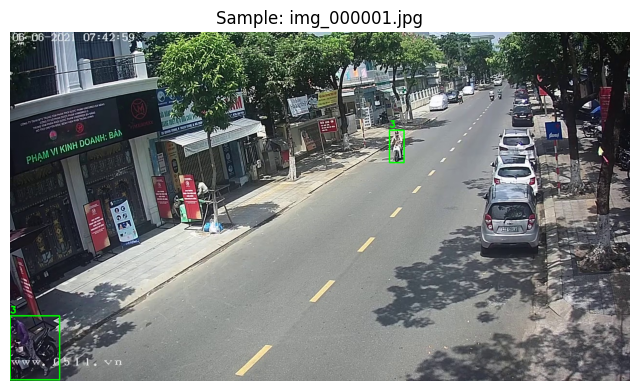

In [7]:
def dataset_stats(images_dir: Path, labels_dir: Path):
    pairs = []
    class_counts = Counter()
    for img_path in sorted(images_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        label_path = labels_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            continue
        labels = load_yolo_labels(label_path)
        pairs.append((img_path, label_path))
        for cls_id, *_ in labels:
            class_counts[cls_id] += 1
    return len(pairs), sum(class_counts.values()), class_counts


def draw_sample_with_bboxes(images_dir: Path, labels_dir: Path, sample_index: int = 0):
    pairs = []
    for img_path in sorted(images_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        label_path = labels_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            pairs.append((img_path, label_path))
    if not pairs:
        print("No image/label pairs found.")
        return
    img_path, label_path = pairs[sample_index % len(pairs)]
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Failed to read image: {img_path}")
        return
    labels = load_yolo_labels(label_path)
    h, w = img.shape[:2]
    for cls_id, x, y, bw, bh in labels:
        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, str(cls_id), (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Sample: {img_path.name}")
    plt.axis("off")
    plt.show()


final_images, final_labels, final_counts = dataset_stats(OUT_IMAGES_DIR, OUT_LABELS_DIR)
print(f"Final images: {final_images}")
print(f"Final labels: {final_labels}")
print("Class counts:", dict(final_counts))

draw_sample_with_bboxes(OUT_IMAGES_DIR, OUT_LABELS_DIR, sample_index=0)

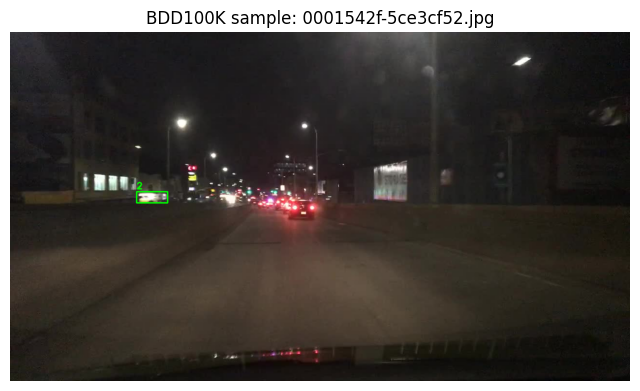

In [8]:
# Ve mot anh mau tu BDD100K sau khi map (motor/bus/truck)
if bdd_pairs:
    sample_img_path, sample_labels = bdd_pairs[0]
    img = cv2.imread(str(sample_img_path))
    if img is None:
        print(f"Failed to read image: {sample_img_path}")
    else:
        h, w = img.shape[:2]
        for cls_id, x, y, bw, bh in sample_labels:
            x1 = int((x - bw / 2) * w)
            y1 = int((y - bh / 2) * h)
            x2 = int((x + bw / 2) * w)
            y2 = int((y + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, str(cls_id), (x1, max(0, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.title(f"BDD100K sample: {sample_img_path.name}")
        plt.axis("off")
        plt.show()
else:
    print("No BDD100K samples found.")